# Marketing Campaign Performance Tracker — Fitness Studio
### SafeX Solutions — Data Science Internship — Weekly Task (Group 50- Muhammad Faez Salman)

**Task:** Build a Marketing Campaign Performance Tracker for a Fitness Studio using
Python (pandas/NumPy) and Matplotlib/Seaborn in Jupyter Notebook — analyzing channel
effectiveness, campaign types, ROI trends, and audience segments to guide budget
allocation.

**Dataset used:** [Marketing Campaign Performance Dataset](https://www.kaggle.com/datasets/manishabhatt22/marketing-campaign-performance-dataset)
(file: `marketing_campaign_dataset.csv`) — ~200,000 campaign records on Kaggle, across 5
campaign types, multiple channels, customer segments, and 2 years of dates.


## 1. Import Libraries & Setup

In [9]:
# ==========================================
# CELL 1: Import Libraries & Setup
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# Setting up visualization style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load Dataset & Preview

In [10]:
# ==========================================
# CELL 2: Load Dataset & Preview
# ==========================================
df = pd.read_csv('marketing_campaign_dataset.csv')
print("\n--- First 10 Rows ---")
print(df.head(10))


--- First 10 Rows ---
   Campaign_ID            Company Campaign_Type Target_Audience Duration  \
0            1          NovaWorks    Influencer     Women 25-34  45 days   
1            2       Vertex Media       Display     Women 25-34  30 days   
2            3   Crestline Brands        Search       Men 25-34  60 days   
3            4           TechCorp       Display       Men 18-24  30 days   
4            5  Alpha Innovations        Search       Men 35-44  30 days   
5            6    Peak Fitness Co  Social Media       Men 35-44  30 days   
6            7  Alpha Innovations    Influencer     Women 25-34  15 days   
7            8           TechCorp       Display       Men 18-24  60 days   
8            9          NovaWorks    Influencer     Women 25-34  45 days   
9           10          NovaWorks  Social Media     Women 25-34  60 days   

  Channel_Used  Conversion_Rate Acquisition_Cost   ROI     Location  Language  \
0      YouTube           0.0641       $13,980.80  4.71     

## 3. Basic Data Information & Dimensions

In [11]:
# ==========================================
# CELL 3: Basic Data Information & Dimensions
# ==========================================
print("\n=== DATASET BASIC INFORMATION ===")
print(f"Dataset Dimensions: {df.shape[0]} rows x {df.shape[1]} columns")
print("\nColumn Names and Data Types:")
print(df.dtypes)


=== DATASET BASIC INFORMATION ===
Dataset Dimensions: 8006 rows x 16 columns

Column Names and Data Types:
Campaign_ID           int64
Company              object
Campaign_Type        object
Target_Audience      object
Duration             object
Channel_Used         object
Conversion_Rate     float64
Acquisition_Cost     object
ROI                 float64
Location             object
Language             object
Clicks                int64
Impressions           int64
Engagement_Score    float64
Customer_Segment     object
Date                 object
dtype: object


## 4. Missing Values & Dataset Summary

In [12]:
# ==========================================
# CELL 4: Missing Values & Dataset Summary
# ==========================================
print("\nMissing Values (count):")
print(df.isnull().sum())

print("\nMissing Values (% of column):")
print((df.isnull().mean() * 100).round(2))

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nDataset Summary:")
df.info()


Missing Values (count):
Campaign_ID          0
Company              0
Campaign_Type        0
Target_Audience      0
Duration             0
Channel_Used         0
Conversion_Rate      0
Acquisition_Cost     0
ROI                  0
Location             0
Language             0
Clicks               0
Impressions          0
Engagement_Score    66
Customer_Segment     0
Date                 0
dtype: int64

Missing Values (% of column):
Campaign_ID         0.00
Company             0.00
Campaign_Type       0.00
Target_Audience     0.00
Duration            0.00
Channel_Used        0.00
Conversion_Rate     0.00
Acquisition_Cost    0.00
ROI                 0.00
Location            0.00
Language            0.00
Clicks              0.00
Impressions         0.00
Engagement_Score    0.82
Customer_Segment    0.00
Date                0.00
dtype: float64

Duplicate Rows: 0

Dataset Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8006 entries, 0 to 8005
Data columns (total 16 columns):
 #  

## 5. Data Cleaning & Feature Engineering

In [13]:
# ==========================================
# CELL 5: Data Cleaning & Feature Engineering
# ==========================================
print("\n=== DATA CLEANING AND TYPE CONVERSION ===")

# Convert Date column to datetime and extract time-based features
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['MonthName'] = df['Date'].dt.month_name()
df['Quarter'] = df['Date'].dt.quarter

# Acquisition_Cost sometimes arrives as a currency string (e.g. "$16,174.00").
# Strip any $ and , characters before converting to numeric. Running this
# unconditionally (rather than gating on dtype) is safer: pandas can infer
# plain-string columns under a non-"object" dtype depending on version, and
# str.replace is a harmless no-op on values that are already clean numbers.
df['Acquisition_Cost'] = (
    df['Acquisition_Cost'].astype(str).str.replace(r'[$,]', '', regex=True)
)
df['Acquisition_Cost'] = pd.to_numeric(df['Acquisition_Cost'], errors='coerce')

# Format core numeric columns explicitly
numeric_columns = ['Conversion_Rate', 'ROI', 'Clicks', 'Impressions', 'Engagement_Score']
for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Duration can arrive as "30 days" or a plain number - extract the numeric part
if 'Duration' in df.columns:
    df['Duration_Days'] = df['Duration'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

# Drop rows missing the fields essential to this analysis
essential_cols = [c for c in ['Date', 'Campaign_Type', 'Channel_Used', 'ROI', 'Conversion_Rate']
                   if c in df.columns]
df = df.dropna(subset=essential_cols)
df = df.drop_duplicates()

# Feature engineering: efficiency metrics used throughout the tracker
df['CTR'] = np.where(df['Impressions'] > 0, (df['Clicks'] / df['Impressions']) * 100, np.nan)
df['Cost_Per_Click'] = np.where(df['Clicks'] > 0, df['Acquisition_Cost'] / df['Clicks'], np.nan)

print("\nData types after cleaning:")
print(df.dtypes)
print(f"\nDate range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Final dataset shape after cleaning: {df.shape[0]} rows x {df.shape[1]} columns")


=== DATA CLEANING AND TYPE CONVERSION ===

Data types after cleaning:
Campaign_ID                  int64
Company                     object
Campaign_Type               object
Target_Audience             object
Duration                    object
Channel_Used                object
Conversion_Rate            float64
Acquisition_Cost           float64
ROI                        float64
Location                    object
Language                    object
Clicks                       int64
Impressions                  int64
Engagement_Score           float64
Customer_Segment            object
Date                datetime64[ns]
Year                       float64
Month                      float64
MonthName                   object
Quarter                    float64
Duration_Days              float64
CTR                        float64
Cost_Per_Click             float64
dtype: object

Date range: 2022-01-01 00:00:00 to 2023-12-12 00:00:00
Final dataset shape after cleaning: 3161 rows x 23 col

## 6. Descriptive Statistical Summary

In [14]:
# ==========================================
# CELL 6: Descriptive Statistical Summary
# ==========================================
print("\n=== STATISTICAL SUMMARY ===")
summary_cols = ['Conversion_Rate', 'ROI', 'Acquisition_Cost', 'Clicks',
                 'Impressions', 'Engagement_Score', 'CTR']
summary_cols = [c for c in summary_cols if c in df.columns]
print("Descriptive Statistics for Key Performance Metrics:")
print(df[summary_cols].describe().round(3))


=== STATISTICAL SUMMARY ===
Descriptive Statistics for Key Performance Metrics:
       Conversion_Rate       ROI  Acquisition_Cost    Clicks  Impressions  \
count         3161.000  3161.000          3161.000  3161.000     3161.000   
mean             0.070     5.005         10210.411   549.184     5497.324   
std              0.015     0.597          5612.135   204.635      578.010   
min              0.021     2.830           513.460   200.000     4500.000   
25%              0.060     4.590          5286.530   371.000     4998.000   
50%              0.070     5.000         10218.320   550.000     5497.000   
75%              0.080     5.410         15158.450   737.000     6004.000   
max              0.127     6.770         19999.460   899.000     6499.000   

       Engagement_Score       CTR  
count          3131.000  3161.000  
mean              5.543    10.105  
std               2.888     3.946  
min               1.000     3.132  
25%               3.000     6.702  
50%      

## 7. Campaign Type, Channel & Segment Group Summaries

In [15]:
# ==========================================
# CELL 7: Campaign Type, Channel & Segment Group Summaries
# ==========================================
print("\nCampaign Type-wise Summary:")
campaigntype_summary = df.groupby('Campaign_Type').agg({
    'ROI': ['count', 'mean'],
    'Conversion_Rate': 'mean',
    'Engagement_Score': 'mean'
}).round(3)
print(campaigntype_summary)

print("\nChannel-wise Summary:")
channel_summary = df.groupby('Channel_Used').agg({
    'ROI': ['count', 'mean'],
    'Conversion_Rate': 'mean',
    'Engagement_Score': 'mean'
}).round(3)
print(channel_summary)

if 'Customer_Segment' in df.columns:
    print("\nCustomer Segment-wise Summary:")
    segment_summary = df.groupby('Customer_Segment').agg({
        'ROI': ['count', 'mean'],
        'Conversion_Rate': 'mean',
        'Engagement_Score': 'mean'
    }).round(3)
    print(segment_summary)

    # Dynamic check: does this dataset include a fitness/wellness-flavored segment
    # or company we can spotlight for the "fitness studio" framing?
    fitness_keywords = ['fit', 'health', 'gym', 'wellness', 'sport', 'active']
    segment_hits = [s for s in df['Customer_Segment'].dropna().unique()
                     if any(k in str(s).lower() for k in fitness_keywords)]
    if segment_hits:
        print(f"\nFitness/wellness-relevant segment(s) found: {segment_hits}")
    else:
        print("\nNo fitness/wellness-specific segment in this dataset - "
              "the tracker below compares performance across all available segments instead.")


Campaign Type-wise Summary:
                ROI        Conversion_Rate Engagement_Score
              count   mean            mean             mean
Campaign_Type                                              
Display         656  4.996           0.069            5.554
Email           631  4.985           0.071            5.502
Influencer      579  5.052           0.070            5.443
Search          648  5.013           0.069            5.657
Social Media    647  4.986           0.070            5.549

Channel-wise Summary:
               ROI        Conversion_Rate Engagement_Score
             count   mean            mean             mean
Channel_Used                                              
Email          710  5.020            0.07            5.487
Google Ads     616  4.972            0.07            5.419
Instagram      642  5.035            0.07            5.705
Website        619  5.006            0.07            5.557
YouTube        574  4.989            0.07            5.

## 8. Monthly Performance Trend Calculation

In [16]:
# ==========================================
# CELL 8: Monthly Performance Trend Calculation
# ==========================================
print("\n=== MONTHLY PERFORMANCE TREND ===")

monthly_performance = df.groupby(['Year', 'Month', 'MonthName']).agg({
    'ROI': 'mean',
    'Conversion_Rate': 'mean',
    'Acquisition_Cost': 'mean'
}).reset_index()

monthly_performance = monthly_performance.sort_values(['Year', 'Month'])
monthly_performance['Period'] = (
    monthly_performance['MonthName'].str[:3] + " " + monthly_performance['Year'].astype(str)
)
print("\nMonthly Performance Summary (first 10 rows):")
print(monthly_performance.head(10))


=== MONTHLY PERFORMANCE TREND ===

Monthly Performance Summary (first 10 rows):
     Year  Month  MonthName       ROI  Conversion_Rate  Acquisition_Cost  \
0  2022.0    1.0    January  4.891724         0.069542      10490.347759   
1  2022.0    2.0   February  5.022137         0.070685      10497.505043   
2  2022.0    3.0      March  4.971120         0.068826      10245.268960   
3  2022.0    4.0      April  5.028702         0.069050      10429.386183   
4  2022.0    5.0        May  5.015734         0.072117      10315.592308   
5  2022.0    6.0       June  5.106281         0.069912      10073.210579   
6  2022.0    7.0       July  5.065971         0.069906       9451.185899   
7  2022.0    8.0     August  5.097080         0.071183      10242.784336   
8  2022.0    9.0  September  5.083109         0.069318      10099.893782   
9  2022.0   10.0    October  5.027239         0.069284      10683.598881   

       Period  
0  Jan 2022.0  
1  Feb 2022.0  
2  Mar 2022.0  
3  Apr 2022.0  
4 

## 9. Visualization 1 — Monthly Average ROI Trend (Line Chart)

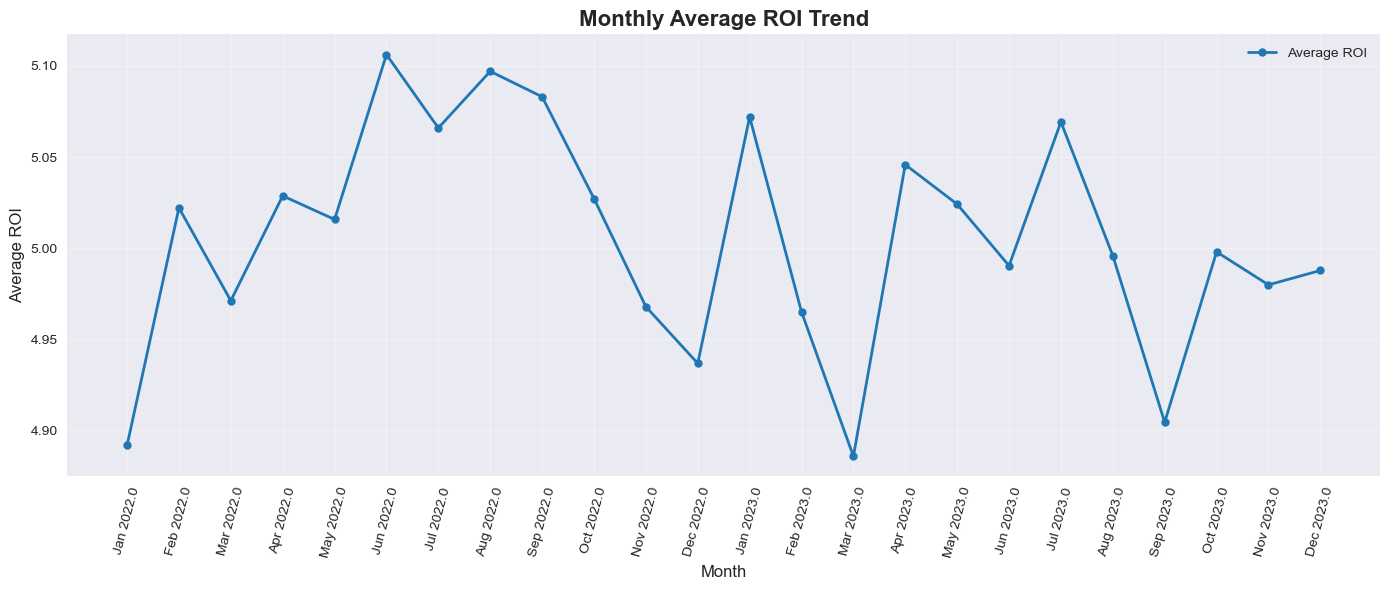

In [17]:
plt.figure(figsize=(14, 6))
plt.plot(monthly_performance['Period'], monthly_performance['ROI'],
         marker='o', linewidth=2, markersize=6, color='#1f77b4', label='Average ROI')
plt.title('Monthly Average ROI Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average ROI', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

## 10. Campaign Type Performance Analysis

In [18]:
# ==========================================
# CELL 10: Campaign Type Performance Analysis
# ==========================================
print("\n=== CAMPAIGN TYPE PERFORMANCE ANALYSIS ===")

campaigntype_performance = df.groupby('Campaign_Type')['ROI'].mean().sort_values(ascending=False)
print("Average ROI by Campaign Type (Sorted):")
print(campaigntype_performance.round(3))


=== CAMPAIGN TYPE PERFORMANCE ANALYSIS ===
Average ROI by Campaign Type (Sorted):
Campaign_Type
Influencer      5.052
Search          5.013
Display         4.996
Social Media    4.986
Email           4.985
Name: ROI, dtype: float64


## 11. Visualization 2 — Average ROI by Campaign Type (Bar Chart)

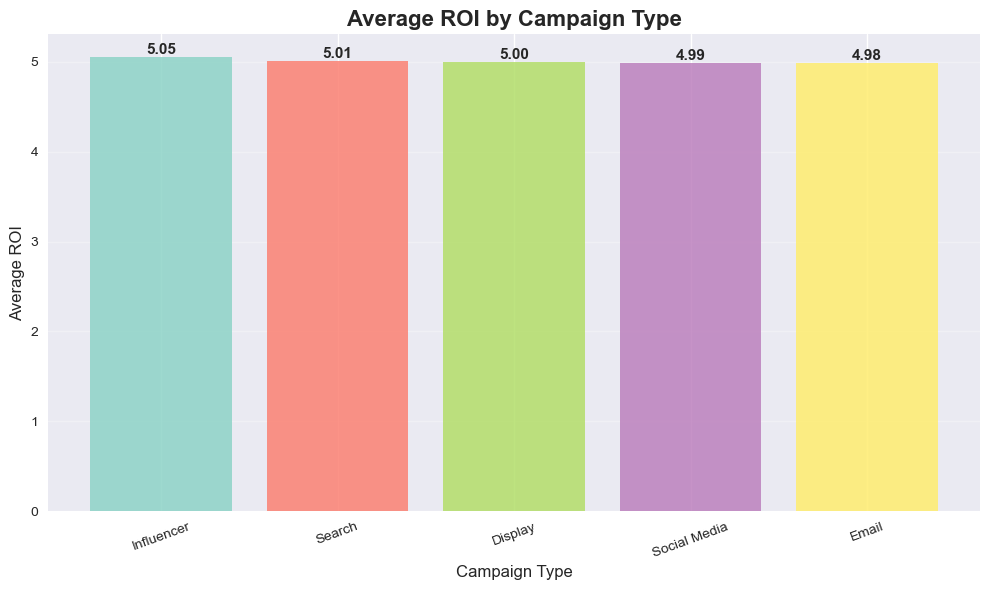

In [19]:
plt.figure(figsize=(10, 6))
colors = plt.cm.Set3(np.linspace(0, 1, len(campaigntype_performance)))
bars = plt.bar(campaigntype_performance.index, campaigntype_performance.values,
               color=colors, alpha=0.85)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Average ROI by Campaign Type', fontsize=16, fontweight='bold')
plt.xlabel('Campaign Type', fontsize=12)
plt.ylabel('Average ROI', fontsize=12)
plt.xticks(rotation=20)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Customer Segment Analysis + Visualization 3 (Pie Chart)


=== CUSTOMER SEGMENT ANALYSIS ===
Campaign Volume by Segment:
Customer_Segment
Health & Fitness       672
Tech Enthusiasts       629
Fashionistas           626
Foodies                621
Outdoor Adventurers    613
Name: count, dtype: int64

Average ROI by Segment:
Customer_Segment
Tech Enthusiasts       5.024
Foodies                5.021
Outdoor Adventurers    5.015
Health & Fitness       4.985
Fashionistas           4.983
Name: ROI, dtype: float64


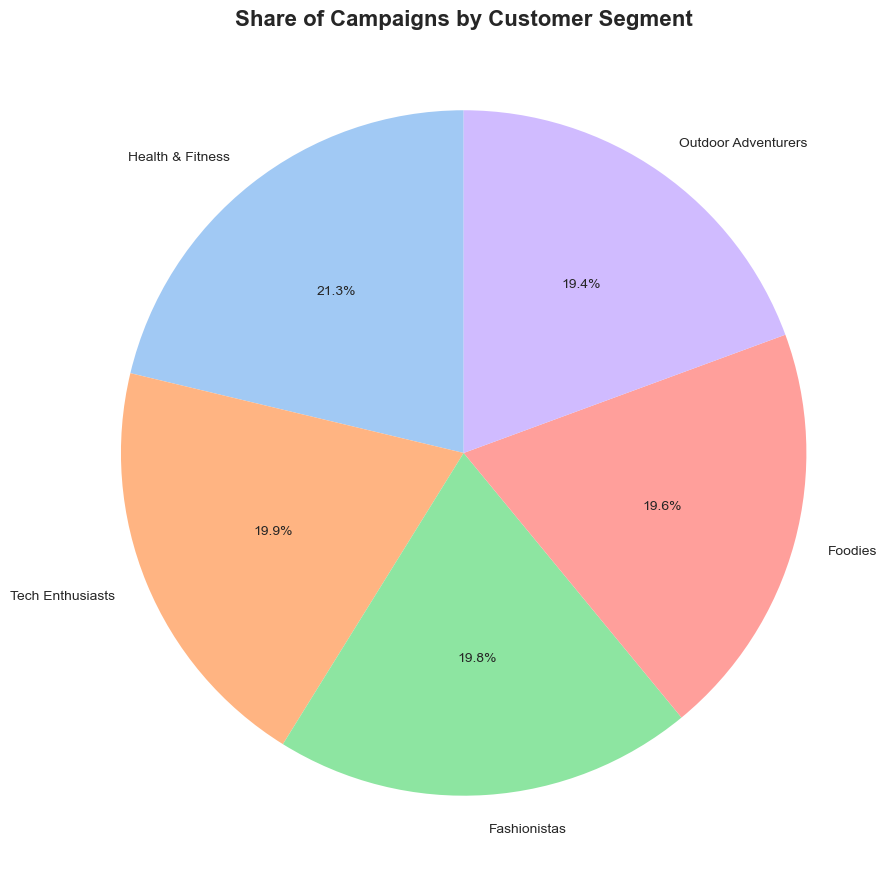

In [20]:
# ==========================================
# CELL 12: Customer Segment Analysis
# ==========================================
print("\n=== CUSTOMER SEGMENT ANALYSIS ===")

segment_counts = df['Customer_Segment'].value_counts()
segment_roi = df.groupby('Customer_Segment')['ROI'].mean().round(3)
print("Campaign Volume by Segment:")
print(segment_counts)
print("\nAverage ROI by Segment:")
print(segment_roi.sort_values(ascending=False))

# Visualization 3: Share of campaigns by customer segment
plt.figure(figsize=(9, 9))
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%',
        startangle=90, colors=sns.color_palette('pastel'))
plt.title('Share of Campaigns by Customer Segment', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

## 13. Channel Effectiveness Analysis + Visualization 4 (Bar Chart)


=== CHANNEL EFFECTIVENESS ANALYSIS ===
Average Engagement Score by Channel:
Channel_Used
Instagram     5.705
Website       5.557
YouTube       5.549
Email         5.487
Google Ads    5.419
Name: Engagement_Score, dtype: float64


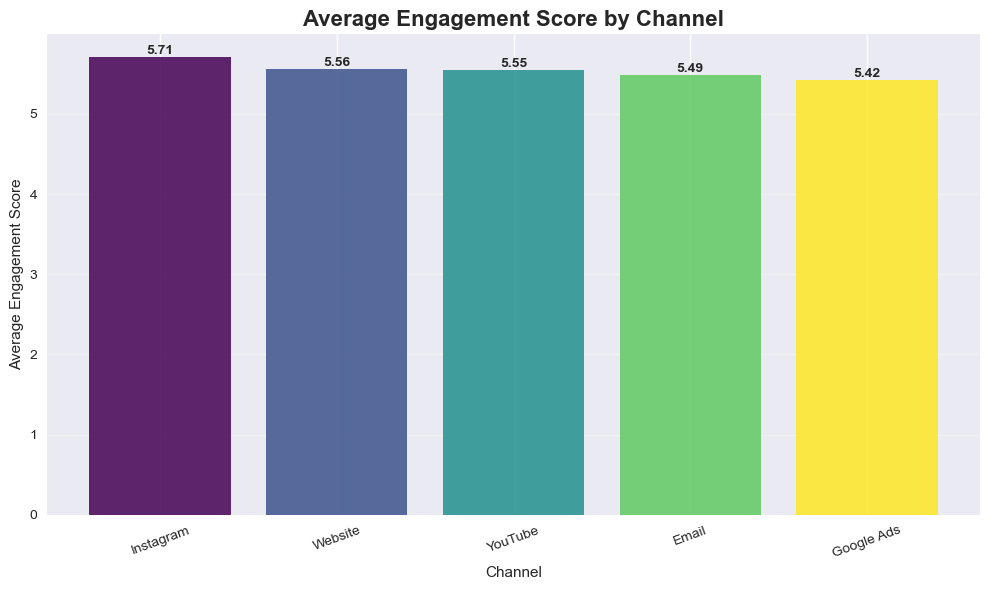

In [21]:
# ==========================================
# CELL 13: Channel Effectiveness Analysis
# ==========================================
print("\n=== CHANNEL EFFECTIVENESS ANALYSIS ===")

channel_engagement = df.groupby('Channel_Used')['Engagement_Score'].mean().sort_values(ascending=False)
print("Average Engagement Score by Channel:")
print(channel_engagement.round(3))

# Visualization 4: Engagement score by channel
plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(channel_engagement)))
bars = plt.bar(channel_engagement.index, channel_engagement.values, color=colors, alpha=0.85)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.title('Average Engagement Score by Channel', fontsize=16, fontweight='bold')
plt.xlabel('Channel')
plt.ylabel('Average Engagement Score')
plt.xticks(rotation=20)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 14. Correlation Matrix & Heatmap


=== CORRELATION ANALYSIS ===
Correlation Matrix:
                  Conversion_Rate   ROI  Acquisition_Cost  Clicks  \
Conversion_Rate              1.00  0.03             -0.01    0.01   
ROI                          0.03  1.00             -0.01   -0.02   
Acquisition_Cost            -0.01 -0.01              1.00    0.02   
Clicks                       0.01 -0.02              0.02    1.00   
Impressions                  0.01 -0.03             -0.02   -0.00   
Engagement_Score            -0.02 -0.02             -0.03   -0.02   
CTR                          0.01 -0.01              0.02    0.96   

                  Impressions  Engagement_Score   CTR  
Conversion_Rate          0.01             -0.02  0.01  
ROI                     -0.03             -0.02 -0.01  
Acquisition_Cost        -0.02             -0.03  0.02  
Clicks                  -0.00             -0.02  0.96  
Impressions              1.00              0.00 -0.28  
Engagement_Score         0.00              1.00 -0.02  
CTR  

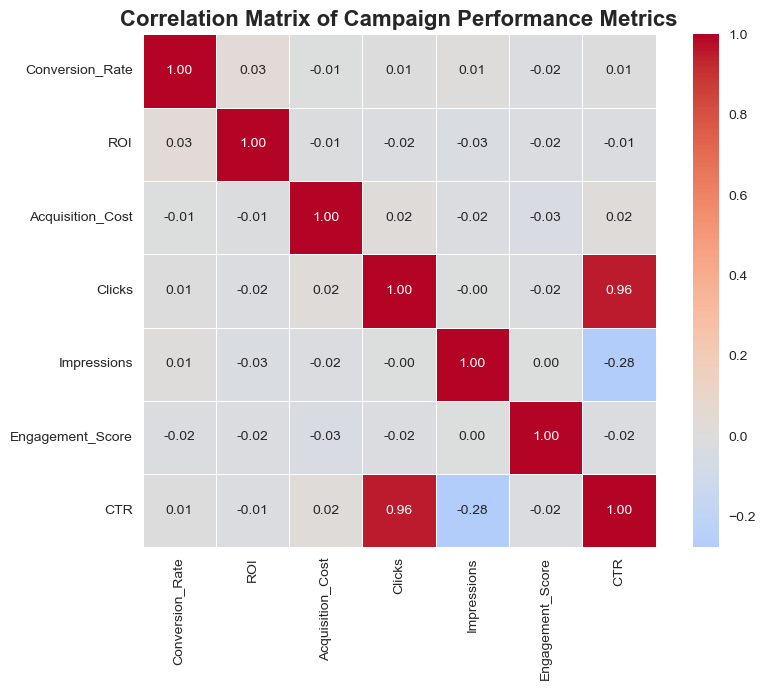

In [22]:
# ==========================================
# CELL 14: Correlation Analysis
# ==========================================
print("\n=== CORRELATION ANALYSIS ===")

corr_cols = ['Conversion_Rate', 'ROI', 'Acquisition_Cost', 'Clicks',
             'Impressions', 'Engagement_Score', 'CTR']
corr_cols = [c for c in corr_cols if c in df.columns]
correlation_matrix = df[corr_cols].corr()

print("Correlation Matrix:")
print(correlation_matrix.round(2))

plt.figure(figsize=(9, 7))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, fmt='.2f')
plt.title('Correlation Matrix of Campaign Performance Metrics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 15. 4-Chart Mini Dashboard


=== 4-CHART MARKETING CAMPAIGN PERFORMANCE DASHBOARD ===


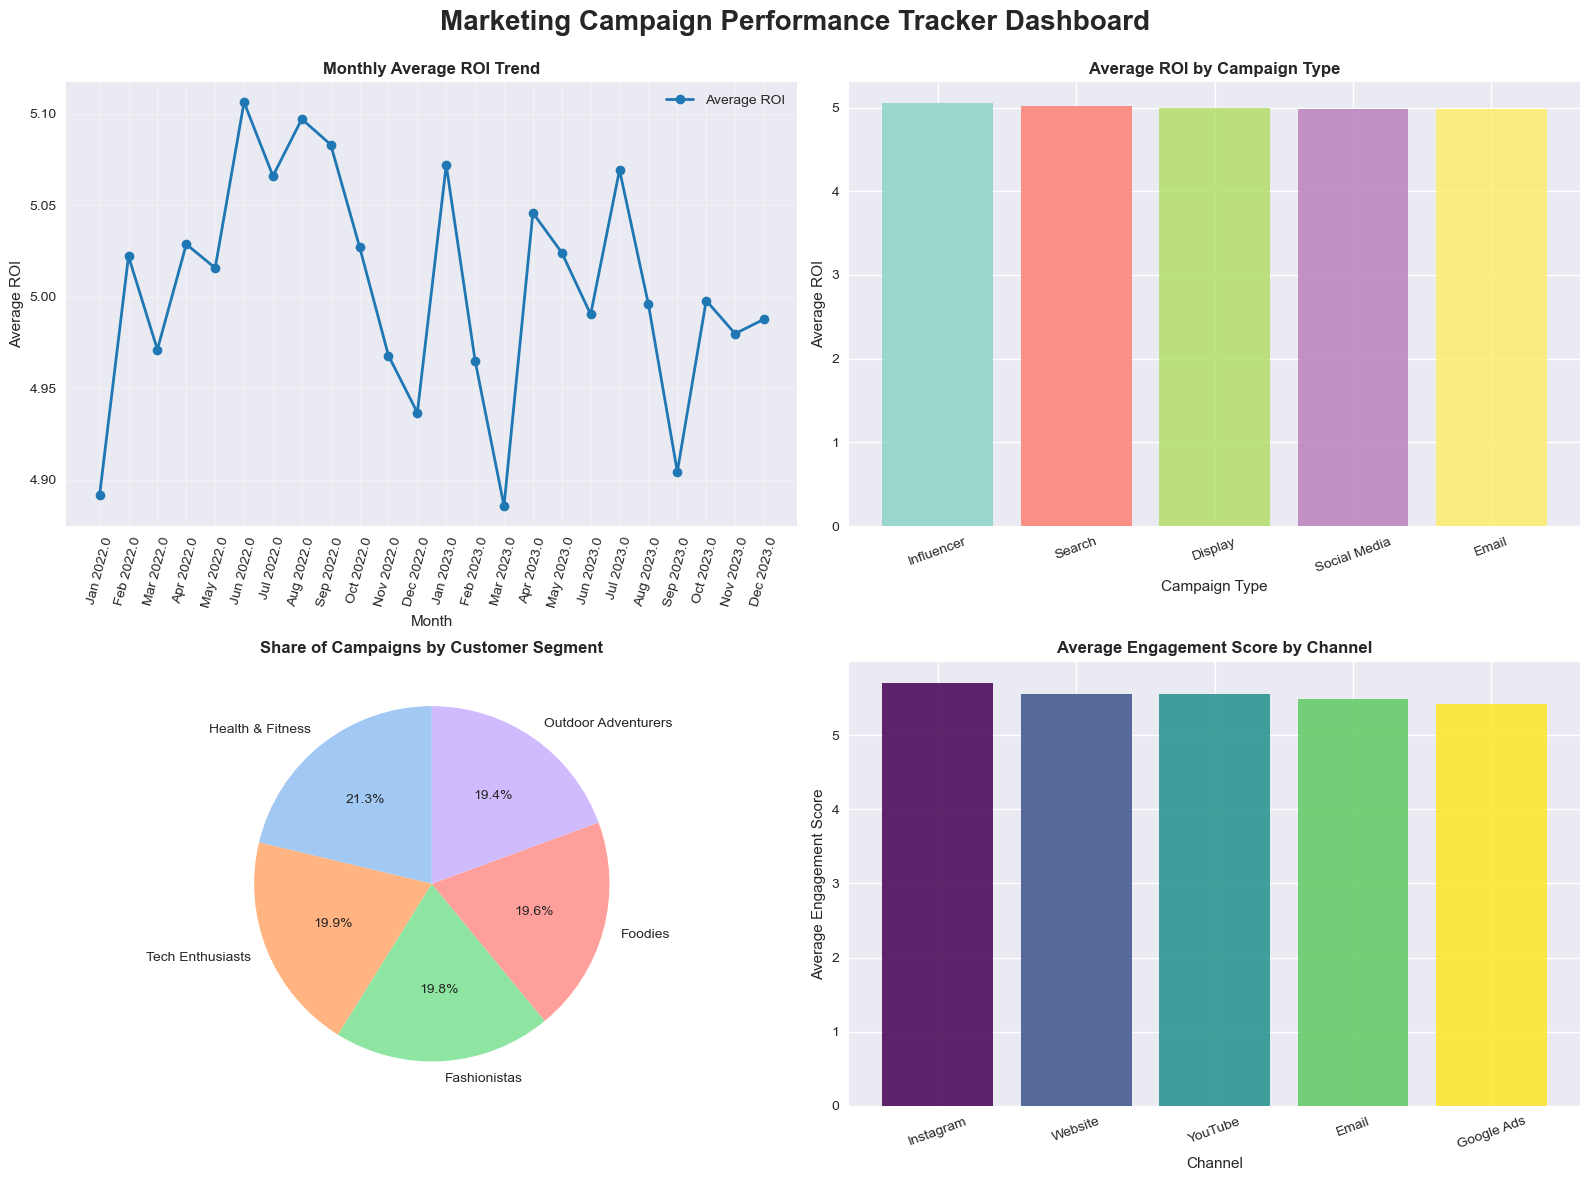

In [23]:
# ==========================================
# CELL 15: 4-CHART MARKETING CAMPAIGN PERFORMANCE DASHBOARD
# ==========================================
print("\n=== 4-CHART MARKETING CAMPAIGN PERFORMANCE DASHBOARD ===")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Marketing Campaign Performance Tracker Dashboard', fontsize=20, fontweight='bold')

# Chart 1: Monthly ROI Trend (Top-Left)
axes[0, 0].plot(monthly_performance['Period'], monthly_performance['ROI'],
                marker='o', linewidth=2, color='#1f77b4', label='Average ROI')
axes[0, 0].set_title('Monthly Average ROI Trend', fontweight='bold')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Average ROI')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=75)

# Chart 2: Average ROI by Campaign Type (Top-Right)
colors = plt.cm.Set3(np.linspace(0, 1, len(campaigntype_performance)))
axes[0, 1].bar(campaigntype_performance.index, campaigntype_performance.values,
               color=colors, alpha=0.85)
axes[0, 1].set_title('Average ROI by Campaign Type', fontweight='bold')
axes[0, 1].set_xlabel('Campaign Type')
axes[0, 1].set_ylabel('Average ROI')
axes[0, 1].tick_params(axis='x', rotation=20)

# Chart 3: Campaign Share by Customer Segment (Bottom-Left)
axes[1, 0].pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%',
               startangle=90, colors=sns.color_palette('pastel'))
axes[1, 0].set_title('Share of Campaigns by Customer Segment', fontweight='bold')

# Chart 4: Engagement Score by Channel (Bottom-Right)
colors2 = plt.cm.viridis(np.linspace(0, 1, len(channel_engagement)))
axes[1, 1].bar(channel_engagement.index, channel_engagement.values, color=colors2, alpha=0.85)
axes[1, 1].set_title('Average Engagement Score by Channel', fontweight='bold')
axes[1, 1].set_xlabel('Channel')
axes[1, 1].set_ylabel('Average Engagement Score')
axes[1, 1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

## 16. Key Insights & Marketing Recommendations

In [24]:
# ==========================================
# CELL 16: Key Insights & Marketing Recommendations
# ==========================================
print("\n=== KEY INSIGHTS AND RECOMMENDATIONS ===")

top_campaign_type = campaigntype_performance.idxmax()
top_channel = channel_engagement.idxmax()
top_segment = segment_roi.idxmax()
busiest_month = monthly_performance.loc[monthly_performance['ROI'].idxmax(), 'Period']

print("\nKEY FINDINGS:")
print(f"1. Top Performing Campaign Type (by ROI): {top_campaign_type}")
print(f"2. Most Engaging Channel: {top_channel}")
print(f"3. Best Performing Customer Segment (by ROI): {top_segment}")
print(f"4. Highest Average-ROI Month: {busiest_month}")
print(f"5. Overall Average ROI: {df['ROI'].mean():.3f}")
print(f"6. Overall Average Conversion Rate: {df['Conversion_Rate'].mean():.3f}")
print(f"7. Overall Average Click-Through Rate (CTR): {df['CTR'].mean():.2f}%")
print(f"8. Total Campaigns Analyzed: {len(df):,}")

print("\nMARKETING RECOMMENDATIONS FOR THE FITNESS STUDIO:")
print(f"1. Prioritize budget toward {top_campaign_type} campaigns - they deliver the strongest ROI.")
print(f"2. Double down on {top_channel} for engagement-driven content (class promos, transformation stories).")
print(f"3. Build segment-specific offers around {top_segment}, the highest-ROI audience segment.")
print(f"4. Time major promotions (new class launches, membership drives) around {busiest_month}-style seasonality.")
print("5. Track Cost_Per_Click alongside ROI - a channel can look cheap but convert poorly, or vice versa.")
print("6. Re-run this notebook monthly with fresh campaign exports to keep the tracker current.")


=== KEY INSIGHTS AND RECOMMENDATIONS ===

KEY FINDINGS:
1. Top Performing Campaign Type (by ROI): Influencer
2. Most Engaging Channel: Instagram
3. Best Performing Customer Segment (by ROI): Tech Enthusiasts
4. Highest Average-ROI Month: Jun 2022.0
5. Overall Average ROI: 5.005
6. Overall Average Conversion Rate: 0.070
7. Overall Average Click-Through Rate (CTR): 10.10%
8. Total Campaigns Analyzed: 3,161

MARKETING RECOMMENDATIONS FOR THE FITNESS STUDIO:
1. Prioritize budget toward Influencer campaigns - they deliver the strongest ROI.
2. Double down on Instagram for engagement-driven content (class promos, transformation stories).
3. Build segment-specific offers around Tech Enthusiasts, the highest-ROI audience segment.
4. Time major promotions (new class launches, membership drives) around Jun 2022.0-style seasonality.
5. Track Cost_Per_Click alongside ROI - a channel can look cheap but convert poorly, or vice versa.
6. Re-run this notebook monthly with fresh campaign exports to ke